In [1]:
import pandas as pd 
import numpy as np 

df = pd.read_csv('tennis_stats.csv')
df.head()

,Player,Year,FirstServe,FirstServePointsWon,FirstServeReturnPointsWon,SecondServePointsWon,SecondServeReturnPointsWon,Aces,BreakPointsConverted,BreakPointsFaced,...,ReturnGamesWon,ReturnPointsWon,ServiceGamesPlayed,ServiceGamesWon,TotalPointsWon,TotalServicePointsWon,Wins,Losses,Winnings,Ranking
0,Pedro Sousa,2016,0.88,0.50,0.38,0.50,0.39,0,0.14,7,...,0.11,0.38,8,0.50,0.43,0.50,1,2,39820,119
1,Roman Safiullin,2017,0.84,0.62,0.26,0.33,0.07,7,0.00,7,...,0.00,0.20,9,0.67,0.41,0.57,0,1,17334,381
2,Pedro Sousa,2017,0.83,0.60,0.28,0.53,0.44,2,0.38,10,...,0.16,0.34,17,0.65,0.45,0.59,4,1,109827,119
3,Rogerio Dutra Silva,2010,0.83,0.64,0.34,0.59,0.33,2,0.33,5,...,0.14,0.34,15,0.80,0.49,0.63,0,0,9761,125
4,Daniel Gimeno-Traver,2017,0.81,0.54,0.00,0.33,0.33,1,0.00,2,...,0.00,0.20,2,0.50,0.35,0.50,0,1,32879,272


In [2]:
df.dtypes

Player                         object
Year                            int64
FirstServe                    float64
FirstServePointsWon           float64
FirstServeReturnPointsWon     float64
SecondServePointsWon          float64
SecondServeReturnPointsWon    float64
Aces                            int64
BreakPointsConverted          float64
BreakPointsFaced                int64
BreakPointsOpportunities        int64
BreakPointsSaved              float64
DoubleFaults                    int64
ReturnGamesPlayed               int64
ReturnGamesWon                float64
ReturnPointsWon               float64
ServiceGamesPlayed              int64
ServiceGamesWon               float64
TotalPointsWon                float64
TotalServicePointsWon         float64
Wins                            int64
Losses                          int64
Winnings                        int64
Ranking                         int64
dtype: object

# Describing Variables 

### Identifying Data
- <code>Player</code>: name of the tennis player 
- <code>Year</code>: year data was recorded 

### Service Game (Offensive)
- <code>FirstServe</code> : % of first serve attempts completed
- <code>FirstServePointsWon</code> : % of first serve points won 
- <code>SecondServePointsWon</code>: % of second serve points won
- <code>Aces</code>: number of aces completed 
- <code>DoubleFaults</code>: number of times player missed both first and second serve
- <code>BreakPointsFaced</code>: number of times the receiver could have won serice game 
- <code>BreakPointsSaved</code>:  % of the time player stopped receiver from winning service game 
- <code>ServiceGamesPlayed</code>: total number of games whre player served 
- <code>ServiceGamesWon</code>: total games player served and won 
- <code>TotalServicePointsWon</code>: % of points in games where player served that they won 

### Return Game (Defensive)
- <code>FirstServeReturnPointsWon</code>: % of opponent first-serve points won  
- <code>SecondServeReturnPointsWon</code>: % of opponent second-serve points won 
- <code>BreakPointsOpportunities</code>: % of the time player was able to win opponent's service game 
- <code>BreakPointsConverted</code>: % of the time player won opponent's service game when they had the chance 
- <code>ReturnGamesPlayed</code>: total number of games where the player's opponent served
- <code>ReturnGamesWon</code>: total number of games where the opponent served and player won 
- <code>ReturnPointsWon</code>: total number of points where the opponent served and player won 
- <code>TotalPointsWon</code>: % of points won by the player 

### Outcomes: 
- <code>Wins</code>: number of matches won in the year 
- <code>Losses</code>: number of matches lost in the year 
- <code>Winnings</code>: total winnings in \$USD in a yar 
- <code>Ranking</code>: ranking at the end of the year

In [3]:
print(f"Data contains {df['Player'].nunique()} unique players")
print(f"Data spanning: {sorted(df['Year'].unique())}")

Data contains 438 unique players
Data spanning: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]


In [4]:
df.describe()

,Year,FirstServe,FirstServePointsWon,FirstServeReturnPointsWon,SecondServePointsWon,SecondServeReturnPointsWon,Aces,BreakPointsConverted,BreakPointsFaced,BreakPointsOpportunities,...,ReturnGamesWon,ReturnPointsWon,ServiceGamesPlayed,ServiceGamesWon,TotalPointsWon,TotalServicePointsWon,Wins,Losses,Winnings,Ranking
count,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,...,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,1721.000000,1.721000e+03,1721.000000
mean,2013.646717,0.598053,0.680738,0.261673,0.479733,0.466432,97.105171,0.369407,112.003486,102.918071,...,0.173823,0.342208,197.650203,0.715590,0.473155,0.599245,7.876816,9.278908,2.344928e+05,269.610691
std,2.488018,0.054533,0.070422,0.056639,0.066902,0.068447,137.966077,0.162987,119.247651,122.761670,...,0.080880,0.049369,221.208703,0.123287,0.037139,0.057718,10.183716,8.996450,2.530537e+05,277.341947
min,2009.000000,0.360000,0.270000,0.000000,0.060000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.220000,0.250000,0.000000,0.000000,1.080000e+02,3.000000
25%,2012.000000,0.570000,0.650000,0.240000,0.460000,0.440000,7.000000,0.320000,15.000000,9.000000,...,0.130000,0.320000,22.000000,0.670000,0.460000,0.570000,0.000000,2.000000,4.931100e+04,83.000000
50%,2014.000000,0.600000,0.690000,0.270000,0.490000,0.480000,34.000000,0.380000,55.000000,41.000000,...,0.180000,0.350000,86.000000,0.750000,0.480000,0.610000,3.000000,5.000000,1.252120e+05,166.000000
75%,2016.000000,0.630000,0.720000,0.290000,0.520000,0.500000,140.000000,0.430000,201.000000,172.000000,...,0.220000,0.370000,348.000000,0.790000,0.500000,0.630000,13.000000,17.000000,3.500750e+05,333.000000
max,2017.000000,0.880000,0.890000,0.480000,0.920000,0.750000,1185.000000,1.000000,507.000000,573.000000,...,0.560000,0.510000,916.000000,1.000000,0.820000,0.820000,48.000000,36.000000,1.074562e+06,1443.000000


# Dealing With Duplicate Values

Duplicates should have the same name and year, as player data can span all 9 years. 

In [5]:
duplicates = df.duplicated()
print(duplicates.value_counts())
print('')

duplicated_data = df[df.duplicated(subset=['Player', 'Year'], keep=False)]
duplicated_data.sort_values(by='Player')

False    1719
True        2
dtype: int64



,Player,Year,FirstServe,FirstServePointsWon,FirstServeReturnPointsWon,SecondServePointsWon,SecondServeReturnPointsWon,Aces,BreakPointsConverted,BreakPointsFaced,...,ReturnGamesWon,ReturnPointsWon,ServiceGamesPlayed,ServiceGamesWon,TotalPointsWon,TotalServicePointsWon,Wins,Losses,Winnings,Ranking
1315,Andrea Arnaboldi,2015,0.57,0.68,0.22,0.50,0.46,23,0.30,52,...,0.13,0.32,64,0.73,0.47,0.60,1,3,154062,222
1317,Andrea Arnaboldi,2015,0.57,0.68,0.22,0.50,0.46,23,0.30,52,...,0.13,0.32,64,0.73,0.47,0.60,1,3,154062,222
935,Facundo Bagnis,2015,0.59,0.64,0.30,0.52,0.45,20,0.43,43,...,0.16,0.35,63,0.68,0.47,0.59,2,4,123931,223
938,Facundo Bagnis,2015,0.59,0.64,0.30,0.52,0.45,20,0.43,43,...,0.16,0.35,63,0.68,0.47,0.59,2,4,123931,223


In [6]:
# Delete duplicate rows (i.e. identical data) 
df = df.drop_duplicates()

duplicates = df.duplicated()
print(duplicates.value_counts())

False    1719
dtype: int64


# Dealing with Missing Values 

We don't see any missing values. Note that all columns are numeric type, so it makes sense to have 

In [7]:
maxRows = df['Player'].count()
print('Missing Rows: ')
print(maxRows - df.count())
print('')

Missing Rows: 
Player                        0
Year                          0
FirstServe                    0
FirstServePointsWon           0
FirstServeReturnPointsWon     0
SecondServePointsWon          0
SecondServeReturnPointsWon    0
Aces                          0
BreakPointsConverted          0
BreakPointsFaced              0
BreakPointsOpportunities      0
BreakPointsSaved              0
DoubleFaults                  0
ReturnGamesPlayed             0
ReturnGamesWon                0
ReturnPointsWon               0
ServiceGamesPlayed            0
ServiceGamesWon               0
TotalPointsWon                0
TotalServicePointsWon         0
Wins                          0
Losses                        0
Winnings                      0
Ranking                       0
dtype: int64



# Establishing Relationships

In [8]:
offensive = ['FirstServe', 'FirstServePointsWon', 'SecondServePointsWon', 'Aces', 'DoubleFaults',
             'BreakPointsFaced', 'BreakPointsSaved', 'ServiceGamesPlayed', 'ServiceGamesWon', 'TotalServicePointsWon']

defensive = ['FirstServeReturnPointsWon', 'SecondServeReturnPointsWon', 'BreakPointsOpportunities',
            'BreakPointsConverted', 'ReturnGamesPlayed', 'ReturnGamesWon', 'ReturnPointsWon', 'TotalPointsWon']

## Offensive Plays

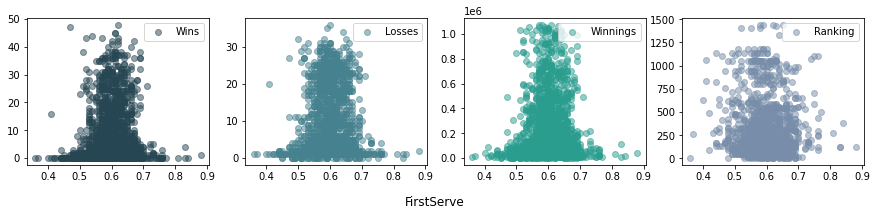

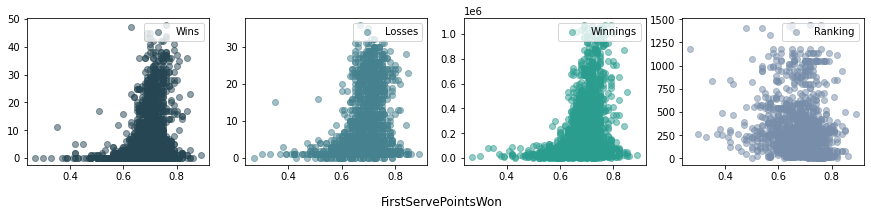

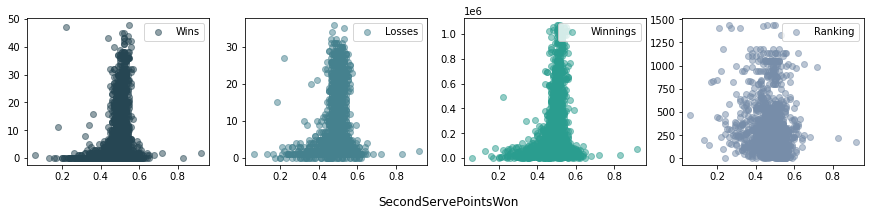

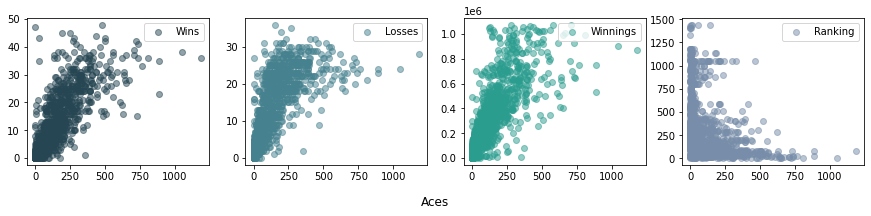

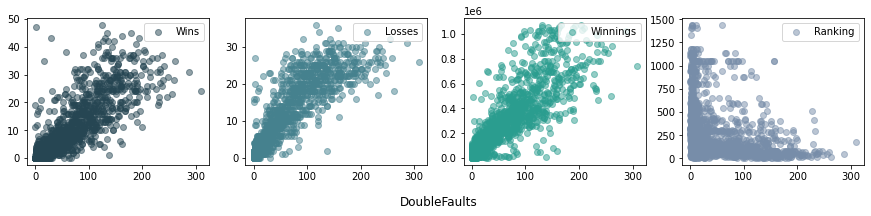

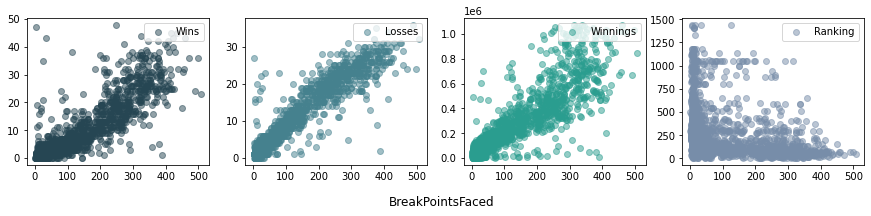

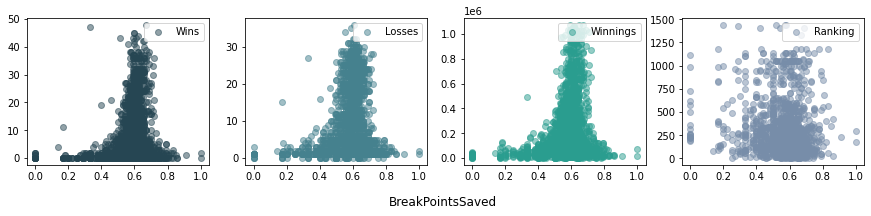

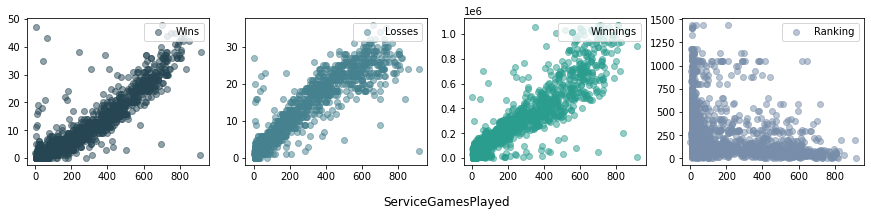

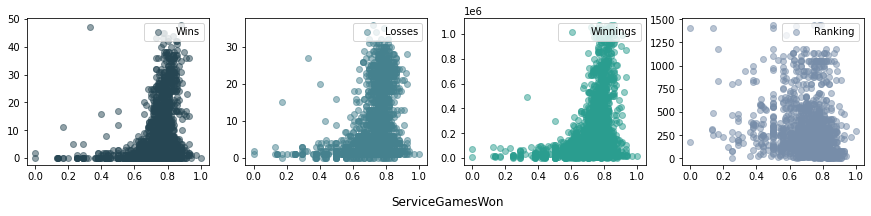

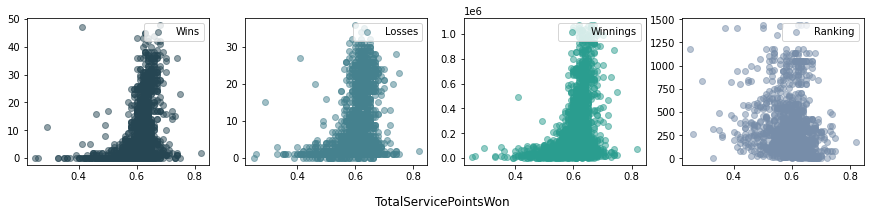

In [50]:
import matplotlib.pyplot as plt

for item in offensive:
    fig, ax = plt.subplots(1, 4, figsize=(15,3))
    ax[0].scatter(df[item], df['Wins'], color='#264653', label='Wins', alpha=0.5)
    ax[0].legend(loc=1)
    
    ax[1].scatter(df[item], df['Losses'], color='#45818e', label='Losses', alpha=0.5)
    ax[1].legend(loc=1)
    
    ax[2].scatter(df[item], df['Winnings'], color='#2A9D8F', label='Winnings', alpha=0.5)
    ax[2].legend(loc=1)
    
    ax[3].scatter(df[item], df['Ranking'], color='#778da9', label='Ranking', alpha=0.5)
    ax[3].legend(loc=1)
    
    fig.text(0.5-len(item)*0.0025, 0.01, item, size=12)
    plt.subplots_adjust(bottom=0.20)

## Defensive Plays

In [10]:
defensive = ['FirstServeReturnPointsWon', 'SecondServeReturnPointsWon', 'BreakPointsOpportunities',
            'BreakPointsConverted', 'ReturnGamesPlayed', 'ReturnGamesWon', 'ReturnPointsWon', 'TotalPointsWon']

for item in defensive:
    print(item)

FirstServeReturnPointsWon
SecondServeReturnPointsWon
BreakPointsOpportunities
BreakPointsConverted
ReturnGamesPlayed
ReturnGamesWon
ReturnPointsWon
TotalPointsWon


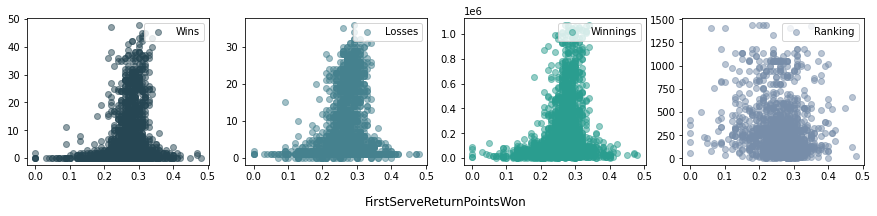

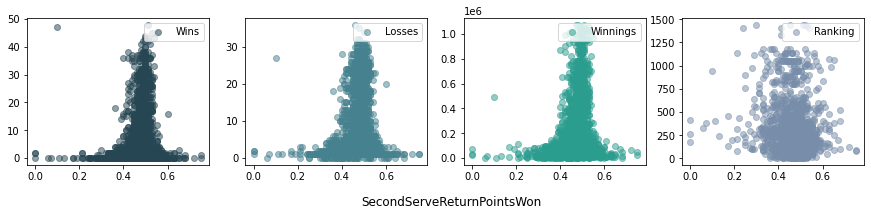

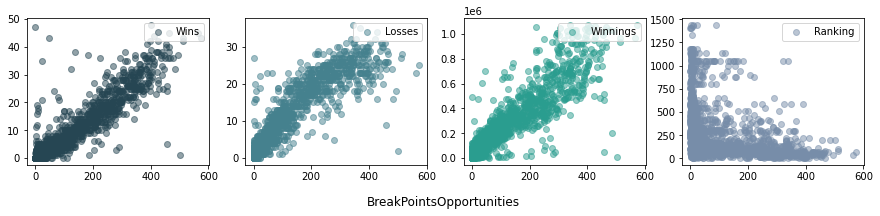

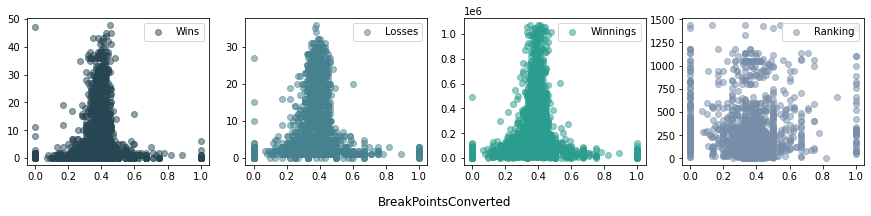

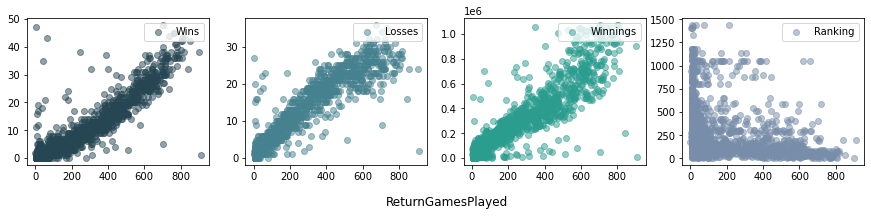

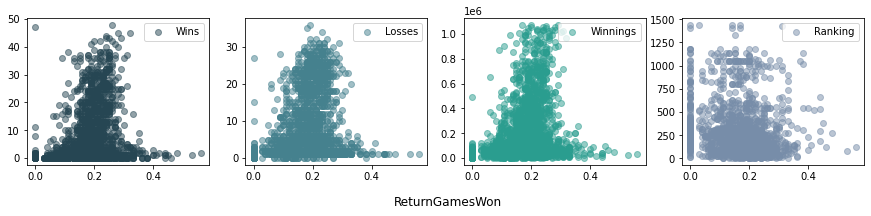

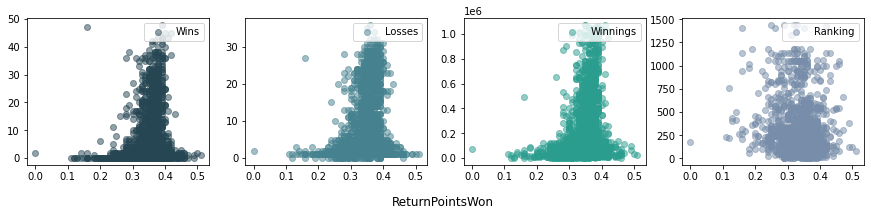

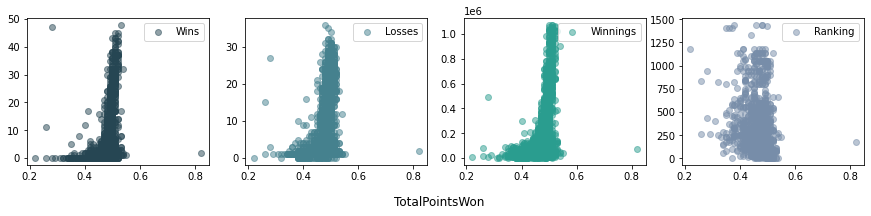

In [51]:
import matplotlib.pyplot as plt

for item in defensive:
    fig, ax = plt.subplots(1, 4, figsize=(15,3))
    ax[0].scatter(df[item], df['Wins'], color='#264653', label='Wins', alpha=0.5)
    ax[0].legend(loc=1)
    
    ax[1].scatter(df[item], df['Losses'], color='#45818e', label='Losses', alpha=0.5)
    ax[1].legend(loc=1)
    
    ax[2].scatter(df[item], df['Winnings'], color='#2A9D8F', label='Winnings', alpha=0.5)
    ax[2].legend(loc=1)
    
    ax[3].scatter(df[item], df['Ranking'], color='#778da9', label='Ranking', alpha=0.5)
    ax[3].legend(loc=1)
    
    fig.text(0.5-len(item)*0.0025, 0.01, item, size=12)
    plt.subplots_adjust(bottom=0.20)

## <u>Relationships established</u>:

<u>Offence</u>: 
- DoubleFaults
- BreakPointsFaced
- ServiceGamesPlayed

<u>Defence</u>: 
- BreakPointsOpportunities
- ReturnGamesPlayed


### Save modified csv for linear regression analysis 

In [13]:
df.to_csv('tennis_stats_clean.csv')